In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

In [3]:
#2. Load Dataset
df = pd.read_csv("Google_Stock_Price.csv", thousands=',')

# Take Open column
data = df['Open'].to_numpy().reshape(-1, 1)

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
data = pd.to_numeric(df['Open'], errors='coerce').dropna().values.reshape(-1, 1)
data_scaled = scaler.fit_transform(data)

In [5]:
train_size = int(len(data_scaled) * 0.8)

train_data = data_scaled[:train_size]
test_data = data_scaled[train_size:]

In [6]:
def create_dataset(dataset):
    X = []
    y = []
    
    for i in range(60, len(dataset)):
        X.append(dataset[i-60:i, 0])
        y.append(dataset[i, 0])
    
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data)
X_test, y_test = create_dataset(test_data)

In [7]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
model = Sequential()

model.add(SimpleRNN(50, return_sequences=True, input_shape=(60,1)))
model.add(SimpleRNN(50))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

NameError: name 'Sequential' is not defined

In [9]:
model.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0124
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.9606e-04
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.9826e-04
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.8661e-04
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.5897e-04
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.6829e-04
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.8268e-04
Epoch 9/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.5972e-04
Epoch 10/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3.5502e-04
Epoch 11/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.1165e-04
Epoch 12/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.3482e-04
Epoch 13/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 2.8550e-04
Epoch 14/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.2856e-04
Epoch 15/20
30/30 ━━━━━━

In [10]:
predicted = model.predict(X_test)

predicted = scaler.inverse_transform(predicted)
real = scaler.inverse_transform(y_test.reshape(-1,1))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step 


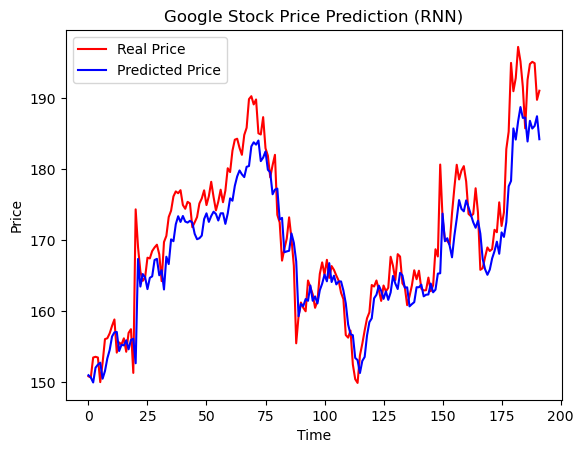

In [11]:
plt.plot(real, color='red', label='Real Price')
plt.plot(predicted, color='blue', label='Predicted Price')

plt.title("Google Stock Price Prediction (RNN)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()